<a href="https://colab.research.google.com/github/Gautamkhushboo/Machine-Vision-LAB/blob/main/practical3(MV_25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q opencv-contrib-python kagglehub

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import random

In [3]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Dataset Path:")
print(path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset Path:
/kaggle/input/gtsrb-german-traffic-sign


In [4]:
for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

/kaggle/input/gtsrb-german-traffic-sign
Folders: ['Meta', 'meta', 'Test', 'test', 'Train']
Files: ['Meta.csv', 'Train.csv', 'Test.csv']
--------------------------------------------------
/kaggle/input/gtsrb-german-traffic-sign/Meta
Folders: []
Files: ['37.png', '35.png', '11.png', '31.png', '4.png']
--------------------------------------------------
/kaggle/input/gtsrb-german-traffic-sign/meta
Folders: []
Files: ['37.png', '35.png', '11.png', '31.png', '4.png']
--------------------------------------------------
/kaggle/input/gtsrb-german-traffic-sign/Test
Folders: []
Files: ['01301.png', '02578.png', '06781.png', '11396.png', '00929.png']
--------------------------------------------------
/kaggle/input/gtsrb-german-traffic-sign/test
Folders: []
Files: ['01301.png', '02578.png', '06781.png', '11396.png', '00929.png']
--------------------------------------------------
/kaggle/input/gtsrb-german-traffic-sign/Train
Folders: ['7', '17', '19', '22', '2']
Files: []
---------------------------

In [5]:
train_path = os.path.join(path, "Train")

print(train_path)

/kaggle/input/gtsrb-german-traffic-sign/Train


In [6]:
reference_images = []
reference_labels = []

for folder in sorted(os.listdir(train_path)):

    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):

        image_list = [f for f in os.listdir(folder_path)
                      if f.endswith((".png",".jpg",".jpeg",".ppm"))]

        if len(image_list) > 0:

            img_path = os.path.join(folder_path, image_list[0])

            img = cv2.imread(img_path)

            if img is not None:

                reference_images.append(img)
                reference_labels.append(folder)

print("Reference Images:", len(reference_images))

Reference Images: 43


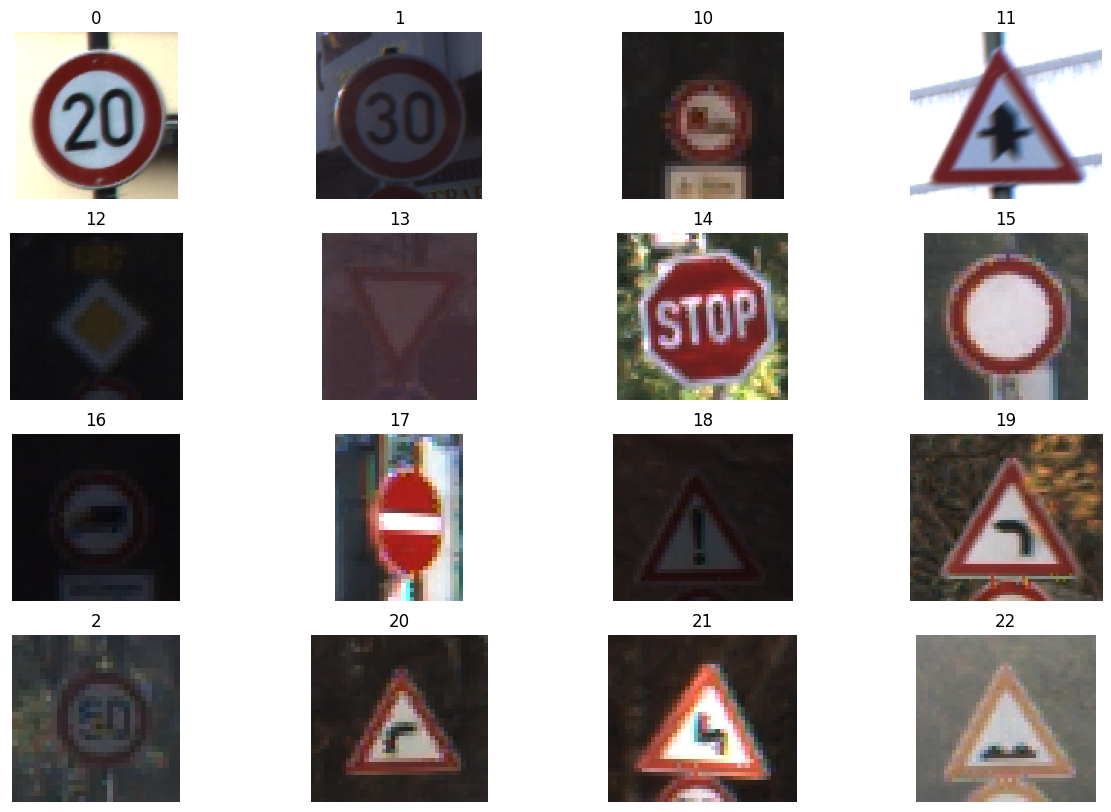

In [7]:
plt.figure(figsize=(15,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(cv2.cvtColor(reference_images[i],cv2.COLOR_BGR2RGB))

    plt.title(reference_labels[i])

    plt.axis("off")

plt.show()

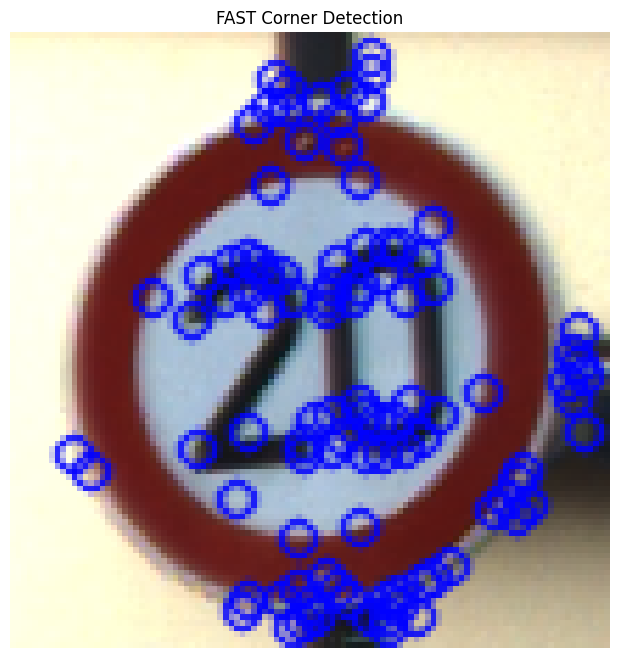

In [8]:
fast = cv2.FastFeatureDetector_create()

sample = reference_images[0]

gray = cv2.cvtColor(sample,cv2.COLOR_BGR2GRAY)

kp = fast.detect(gray,None)

img_fast = cv2.drawKeypoints(sample,kp,None,color=(255,0,0))

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_fast,cv2.COLOR_BGR2RGB))
plt.title("FAST Corner Detection")
plt.axis("off")
plt.show()

In [9]:
orb = cv2.ORB_create(nfeatures=500)

reference_keypoints = []

reference_descriptors = []

for img in reference_images:

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    kp, des = orb.detectAndCompute(gray,None)

    reference_keypoints.append(kp)

    reference_descriptors.append(des)

print("ORB Features Extracted")

ORB Features Extracted


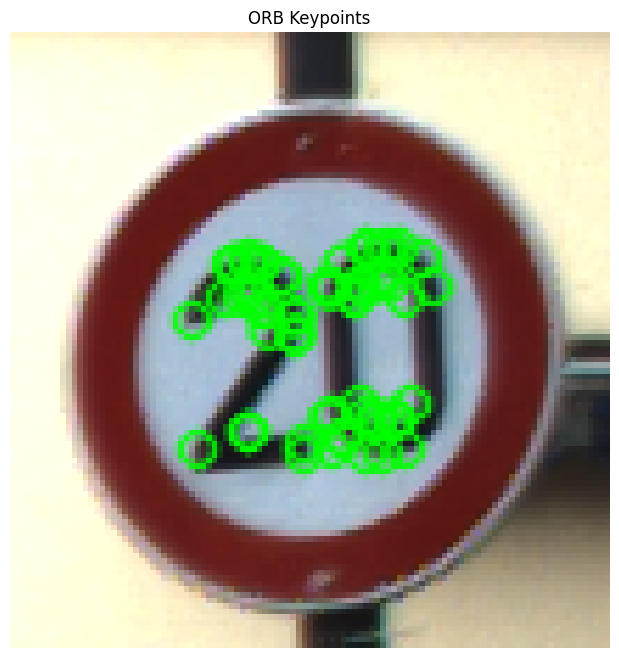

In [10]:
img = reference_images[0]

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

kp, des = orb.detectAndCompute(gray,None)

output = cv2.drawKeypoints(img,kp,None,color=(0,255,0))

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints")
plt.axis("off")
plt.show()

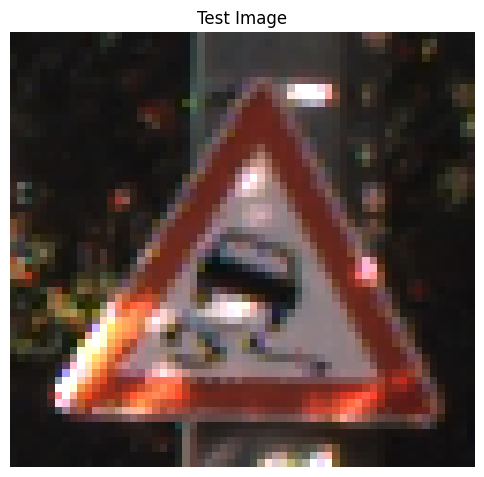

Actual Class: 23


In [11]:
random_class = random.choice(sorted(os.listdir(train_path)))

class_path = os.path.join(train_path, random_class)

images = [f for f in os.listdir(class_path)
          if f.endswith((".png",".jpg",".jpeg",".ppm"))]

random_image = random.choice(images)

test_path = os.path.join(class_path, random_image)

test_img = cv2.imread(test_path)

true_label = random_class

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(test_img,cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis("off")
plt.show()

print("Actual Class:", true_label)

In [12]:
gray = cv2.cvtColor(test_img,cv2.COLOR_BGR2GRAY)

kp_test, des_test = orb.detectAndCompute(gray,None)

print("Keypoints:", len(kp_test))

Keypoints: 0


In [13]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

scores = []

for des in reference_descriptors:

    if des is None or des_test is None:

        scores.append(0)

        continue

    matches = bf.match(des,des_test)

    matches = sorted(matches,key=lambda x:x.distance)

    scores.append(len(matches))

In [14]:
best_index = np.argmax(scores)

predicted_label = reference_labels[best_index]

print("Actual Label    :", true_label)
print("Predicted Label :", predicted_label)

Actual Label    : 23
Predicted Label : 0


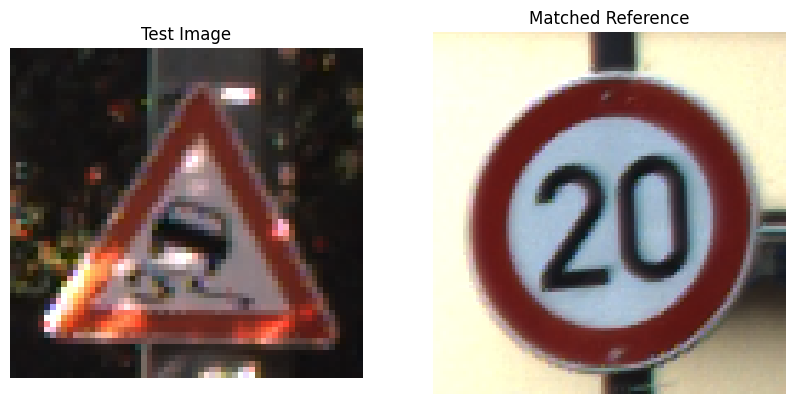

In [15]:
best_image = reference_images[best_index]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(test_img,cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(best_image,cv2.COLOR_BGR2RGB))
plt.title("Matched Reference")
plt.axis("off")

plt.show()

In [17]:
ref_des = reference_descriptors[best_index]
ref_kp = reference_keypoints[best_index]

if ref_des is None or des_test is None:
    print("Cannot perform feature matching: Descriptors are missing for either the reference or test image.")
    if ref_des is None:
        print(f"Reference image (label: {reference_labels[best_index]}) has no descriptors.")
    if des_test is None:
        print("Test image has no descriptors.")
else:
    matches = bf.match(ref_des, des_test)

    matches = sorted(matches,key=lambda x:x.distance)

    matched_img = cv2.drawMatches(
        reference_images[best_index],
        ref_kp,
        test_img,
        kp_test,
        matches[:30],
        None,
        flags=2
    )

    plt.figure(figsize=(18,8))
    plt.imshow(cv2.cvtColor(matched_img,cv2.COLOR_BGR2RGB))
    plt.title("ORB Feature Matching")
    plt.axis("off")
    plt.show()

Cannot perform feature matching: Descriptors are missing for either the reference or test image.
Test image has no descriptors.


In [18]:
correct = 0
total = 0

for folder in sorted(os.listdir(train_path)):

    folder_path = os.path.join(train_path, folder)

    if not os.path.isdir(folder_path):
        continue

    images = [f for f in os.listdir(folder_path)
              if f.endswith((".png",".jpg",".jpeg",".ppm"))][:20]

    for image in images:

        total += 1

        img = cv2.imread(os.path.join(folder_path,image))

        gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

        kp, des = orb.detectAndCompute(gray,None)

        score = []

        for ref in reference_descriptors:

            if ref is None or des is None:
                score.append(0)
                continue

            matches = bf.match(ref,des)

            score.append(len(matches))

        prediction = reference_labels[np.argmax(score)]

        if prediction == folder:

            correct += 1

accuracy = (correct / total) * 100

print("Accuracy = {:.2f}%".format(accuracy))

Accuracy = 2.67%
